![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [1]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
----------------------------------------


✓ numpy 2.4.3
✓ pandas 3.0.1
✓ matplotlib 3.10.8
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [2]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- Respuesta 1: Representa el tiempo que tarda el sistema en acceder a un bloque de datos en el disco desde que se solicita hasta que comienza la lectura. Es el tiempo de espera antes de que realmente se empiece a transferir los datos
- Respuesta 2: Representa la cantidad de datos que se pueden leer o escribir por unidad de tiempo una vez que se ha accedido al bloque. Es la velocidad a la que se transfieren los datos después de superar la latencia inicial.
- Respuesta 3: En el acceso secuencial los datos están organizados de forma continua, por lo que el sistema necesita muy pocos accesos al disco. Por eso se asume que M es cercano a 1, ya que casi todo se lee en un solo recorrido sin saltos.
- Respuesta 4:En el acceso aleatorio los datos están dispersos en diferentes posiciones del disco, por lo que se necesitan muchos accesos independientes para leerlos. Esto hace que M sea mayor, ya que cada salto implica un nuevo tiempo de acceso.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [3]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- Respuesta 1: El tamaño del archivo es de 256 MB, mientras que mi memoria RAM es de 8 GB, por lo que no supera la caché del sistema. Esto puede hacer que parte de los datos se lean desde memoria en lugar del disco. Sin embargo, se utilizó este tamaño para evitar sobrecargar el sistema y permitir una ejecución fluida del experimento
- Respuesta 2: Esperaría que los bloques más grandes (como 64 KB o 256 KB) tengan mejor rendimiento en acceso aleatorio, porque permiten leer más datos en cada acceso y reducen la cantidad de operaciones necesarias, disminuyendo el impacto de la latencia
- Respuesta 3: Estoy ejecutando en local, por lo que los tiempos medidos reflejarán el rendimiento de mi hardware específico

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [8]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

RESET = False. No se eliminó ningún archivo.
Cambie RESET = True si desea repetir el experimento con nuevos parámetros.


## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [4]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

El archivo ya existe y tiene el tamaño esperado.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- Respuesta 1: Este archivo cumple el papel de simular datos almacenados en disco sobre los cuales se realizan las pruebas de acceso secuencial y aleatorio. Permite medir el rendimiento del sistema de almacenamiento bajo diferentes patrones de acceso.
- Respuesta 2: Es útil trabajar con un archivo relativamente grande porque así se aumenta la probabilidad de que los datos no quepan completamente en la memoria RAM, obligando al sistema a leer desde el disco y obteniendo mediciones más realistas del rendimiento
- Respuesta 3: Si el archivo fuera demasiado pequeño, es probable que todos los datos entren en la caché del sistema operativo, lo que haría que los tiempos de acceso no reflejen adecuadamente el rendimiento del almacenamiento en disco.

## 5. Funciones auxiliares de medición

In [5]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [6]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 2.0572 s, throughput: 124.44 MiB/s
Aleatorio  -> tiempo: 0.0870 s, throughput: 179.50 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.2809 s, throughput: 911.40 MiB/s
Aleatorio  -> tiempo: 0.1126 s, throughput: 555.29 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.1455 s, throughput: 1759.19 MiB/s
Aleatorio  -> tiempo: 0.2164 s, throughput: 1155.47 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.1139 s, throughput: 2247.90 MiB/s
Aleatorio  -> tiempo: 0.6720 s, throughput: 1488.17 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,2.057240,124.438586,4.0
1,Aleatorio,4096,16384000,4000,0.087047,179.500936,4.0
2,Secuencial,16384,268435456,16384,0.280887,911.398858,16.0
3,Aleatorio,16384,65536000,4000,0.112553,555.292964,16.0
4,Secuencial,65536,268435456,4096,0.145522,1759.189014,64.0
5,Aleatorio,65536,262144000,4000,0.216361,1155.473594,64.0
6,Secuencial,262144,268435456,1024,0.113884,2247.897426,256.0
7,Aleatorio,262144,1048576000,4000,0.671968,1488.166768,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

- Respuesta 1: Para el bloque de 4 KB, el acceso aleatorio fue más rápido, alcanzando un throughput de 179.50 MiB/s frente a 124.44 MiB/s del acceso secuencial.
Para los bloques de 16 KB, 64 KB y 256 KB, el acceso secuencial fue más rápido. En 16 KB obtuvo 911.40 MiB/s frente a 555.29 MiB/s, en 64 KB alcanzó 1759.19 MiB/s frente a 1155.47 MiB/s, y en 256 KB logró 2247.90 MiB/s frente a 1488.17 MiB/s en acceso aleatorio.

- Respuesta 2: Sí, el throughput cambió al aumentar el tamaño de bloque. En general, los bloques más grandes mostraron un mejor rendimiento en el acceso secuencial, mientras que el acceso aleatorio mostró un rendimiento más consistente.

- Respuesta 3: La mayor diferencia entre acceso secuencial y aleatorio se observó en bloques de 256 KB. En este caso, el acceso secuencial obtuvo 2247.90 MiB/s mientras que el acceso aleatorio alcanzó 1488.17 MiB/s, con una diferencia aproximada de 759.73 MiB/s. Esto muestra claramente que el acceso secuencial es mucho más eficiente cuando se trabaja con bloques grandes.

## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [7]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD SATA aproximado',
    'access_latency_s': 100e-6,  # 100 microsegundos
    'scan_throughput_bytes_s': 500 * (1024**2)  # 500 MB/s
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD SATA aproximado', 'access_latency_s': 0.0001, 'scan_throughput_bytes_s': 524288000}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado:
- Latencia asumida:
- Throughput asumido:

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

- Respuesta : 
Dispositivo modelado: SSD SATA aproximado
Latencia asumida: 100 µs (100e-6 s)
Throughput asumido: 500 MB/s

Elegí un modelo de SSD SATA porque el equipo utilizado cuenta con este tipo de almacenamiento. Este modelo es una aproximación teórica, por lo que puede diferir de los resultados reales debido a factores como la caché del sistema operativo, la carga del CPU y las características específicas del hardware. Aun así, permite tener una referencia para comparar el comportamiento del sistema.

In [8]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.51210,499.902363
1,Aleatorio,4096,4.0,0.43125,36.231884
2,Secuencial,16384,16.0,0.51210,499.902363
3,Aleatorio,16384,16.0,0.52500,119.047619
4,Secuencial,65536,64.0,0.51210,499.902363
5,Aleatorio,65536,64.0,0.90000,277.777778
6,Secuencial,262144,256.0,0.51210,499.902363
7,Aleatorio,262144,256.0,2.40000,416.666667


## 8. Comparación entre resultados empíricos y teóricos

In [10]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,2.057240,124.438586,4.0,0.51210,499.902363,4.017262,0.248926
1,Aleatorio,4096,16384000,4000,0.087047,179.500936,4.0,0.43125,36.231884,0.201848,4.954226
2,Secuencial,16384,268435456,16384,0.280887,911.398858,16.0,0.51210,499.902363,0.548500,1.823154
3,Aleatorio,16384,65536000,4000,0.112553,555.292964,16.0,0.52500,119.047619,0.214387,4.664461
4,Secuencial,65536,268435456,4096,0.145522,1759.189014,64.0,0.51210,499.902363,0.284166,3.519065
5,Aleatorio,65536,262144000,4000,0.216361,1155.473594,64.0,0.90000,277.777778,0.240402,4.159705
6,Secuencial,262144,268435456,1024,0.113884,2247.897426,256.0,0.51210,499.902363,0.222387,4.496673
7,Aleatorio,262144,1048576000,4000,0.671968,1488.166768,256.0,2.40000,416.666667,0.279987,3.571600


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuesta

- Respuesta 1:En la mayoría de los casos, los tiempos empíricos son menores que los teóricos. Por ejemplo, en acceso secuencial con bloques de 256 KB el tiempo empírico fue de aproximadamente 0.1139 s, mientras que el teórico es de 0.5121 s. Esto indica que en la práctica el sistema puede ser más rápido de lo que predice el modelo simplificado.

- Respuesta 2:La teoría se aproxima mejor en el acceso secuencial, ya que los valores teóricos son constantes y más cercanos a los resultados reales en comparación con el acceso aleatorio. En el acceso aleatorio se observan mayores diferencias debido a la variabilidad de los accesos y la latencia acumulada.

- Respuesta 3:Las diferencias entre los resultados teóricos y empíricos pueden explicarse por varios factores del sistema real. En primer lugar, la caché del sistema operativo puede almacenar datos en memoria RAM, reduciendo significativamente los tiempos de acceso. Además, la carga del sistema (como procesos en segundo plano) puede afectar el rendimiento. También influyen características propias del SSD, como el paralelismo interno y el manejo del controlador, que no están considerados en el modelo teórico simplificado.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [11]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\ADMIN\Documents\UDEA 2026-1\ESTRUCTURA DE DATOS Y LAB\lab3-IO_performance-NicoleAdarve\images


Guardada: fig_throughput.png


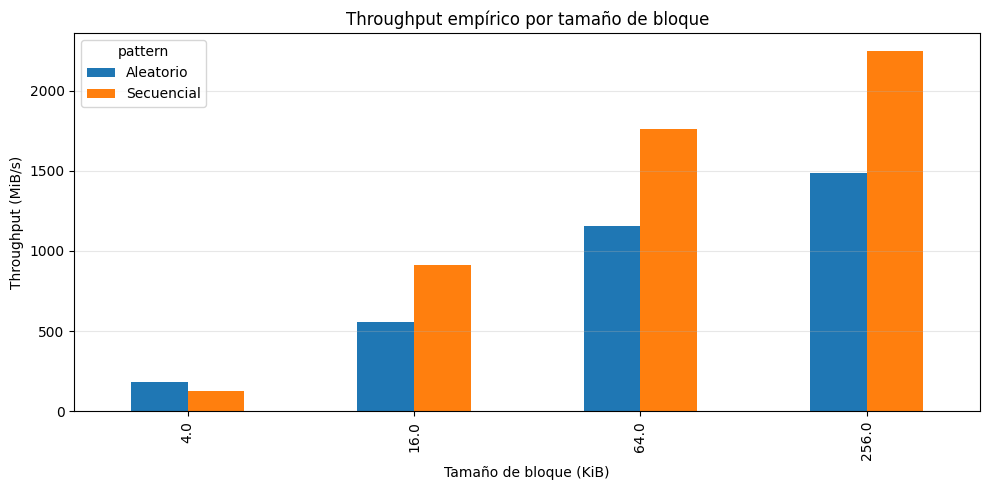

In [12]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- ¿Qué barras son más altas?
- ¿Qué significa eso en términos de rendimiento?
- ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

- ¿Qué barras son más altas? 
Las barras correspondientes al acceso secuencial son más altas que las del acceso aleatorio, especialmente a medida que aumenta el tamaño del bloque. Por ejemplo, con bloques de 256 KB, el acceso secuencial alcanzó un throughput de aproximadamente 2247.90 MiB/s, mientras que el acceso aleatorio obtuvo alrededor de 1488.17 MiB/s
- ¿Qué significa eso en términos de rendimiento?
Esto significa que el acceso secuencial tiene mejor rendimiento, ya que puede transferir más datos por segundo en comparación con el acceso aleatorio. Así que es más eficiente para leer grandes cantidades de información.
- ¿Cuál patrón aprovecha mejor la lectura en bloques?
El patrón de acceso secuencial aprovecha mejor la lectura en bloques, especialmente cuando el tamaño del bloque es mayor. Esto se debe a que permite leer los datos de forma continua, reduciendo la cantidad de accesos al disco. Por ejemplo, en bloques de 256 KB se observa una clara ventaja del acceso secuencial frente al aleatorio.

Guardada: fig_tiempo_empirico.png


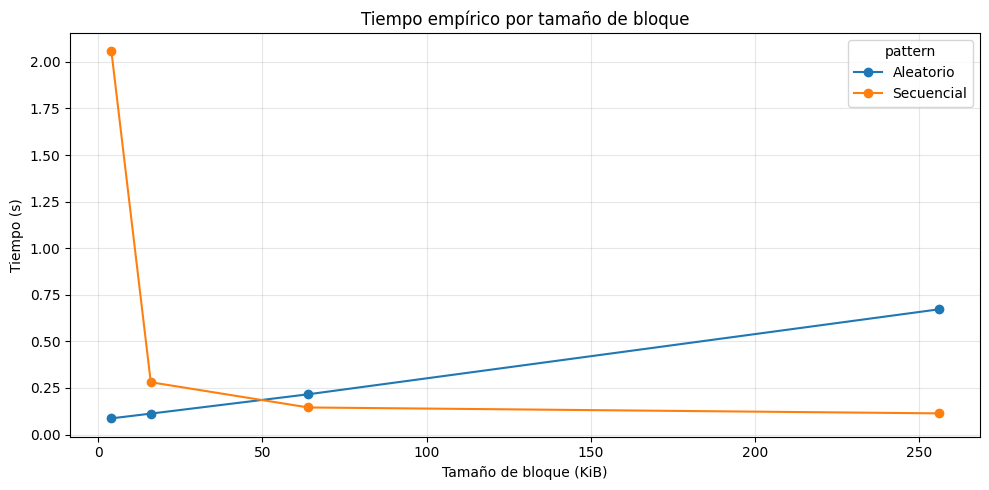

In [13]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta
En la gráfica se observa que el tiempo de acceso secuencial disminuye considerablemente a medida que aumenta el tamaño del bloque. Por ejemplo, en bloques de 4 KB el tiempo es de aproximadamente 2.05 s, mientras que en 256 KB se reduce a cerca de 0.11 s.

Por otro lado, el acceso aleatorio presenta un comportamiento opuesto, ya que el tiempo aumenta conforme crece el tamaño del bloque, pasando de aproximadamente 0.087 s en 4 KB a alrededor de 0.67 s en 256 KB.

La mayor divergencia entre ambas curvas se observa en el tamaño de bloque de 256 KB, donde el acceso secuencial es mucho más rápido (≈0.11 s) en comparación con el acceso aleatorio (≈0.67 s). Esto evidencia que el acceso secuencial es más eficiente para bloques grandes, mientras que el acceso aleatorio se vuelve más costoso a medida que aumenta el tamaño de los datos.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


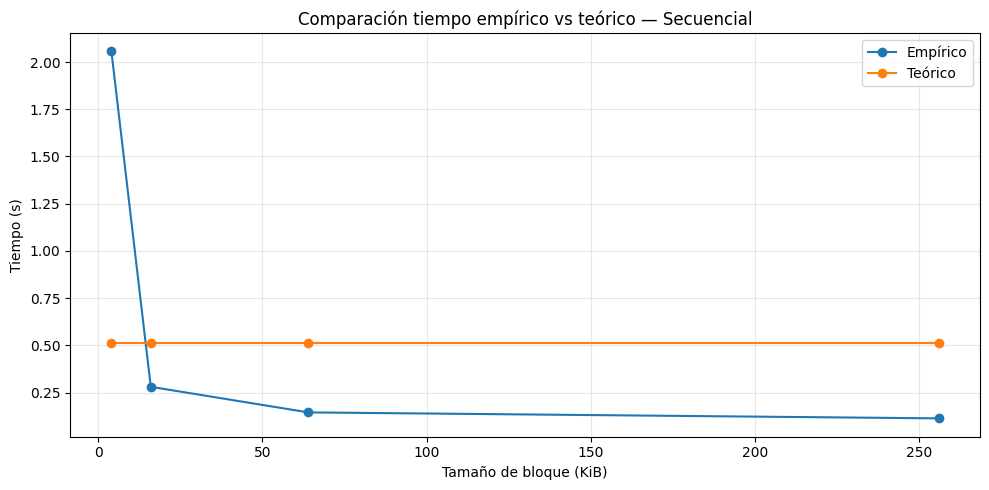

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


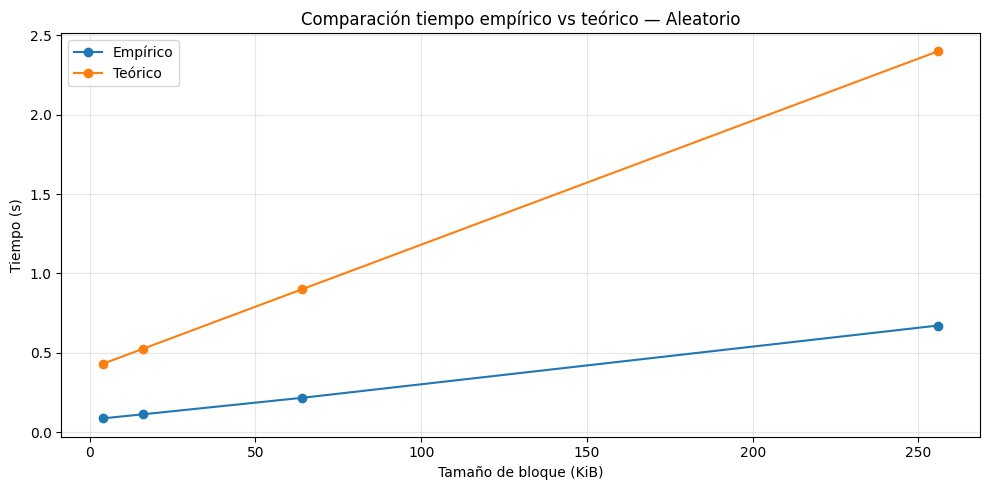

In [17]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

1. ¿Las curvas tienen una tendencia similar?
En el acceso secuencial no tienen una tendencia similar, ya que el tiempo empírico disminuye al aumentar el tamaño del bloque, mientras que el tiempo teórico se mantiene constante.
En el acceso aleatorio sí presentan una tendencia similar, ya que en ambos casos el tiempo aumenta a medida que crece el tamaño del bloque.

2. ¿Dónde se separan más?
En el acceso secuencial, la mayor separación se observa en bloques de 4 KB, donde el tiempo empírico es de aproximadamente 2.05 s, mientras que el teórico es de 0.51 s.
En el acceso aleatorio, la mayor diferencia se presenta en bloques de 256 KB, donde el tiempo teórico alcanza aproximadamente 2.4 s, mientras que el empírico es cercano a 0.67 s.

3. ¿Qué le sugiere eso sobre el modelo usado?
Esto sugiere que el modelo teórico no representa completamente el comportamiento real del sistema. En algunos casos, como el acceso secuencial con bloques grandes, el modelo sobreestima el tiempo real, ya que los valores empíricos son menores.
Estas diferencias pueden explicarse por factores como la caché del sistema operativo, que permite acceder a los datos más rápidamente desde la memoria, y por optimizaciones del SSD como el paralelismo interno y la gestión del controlador, que no están contempladas en el modelo teórico.

Guardada: fig_speedup.png


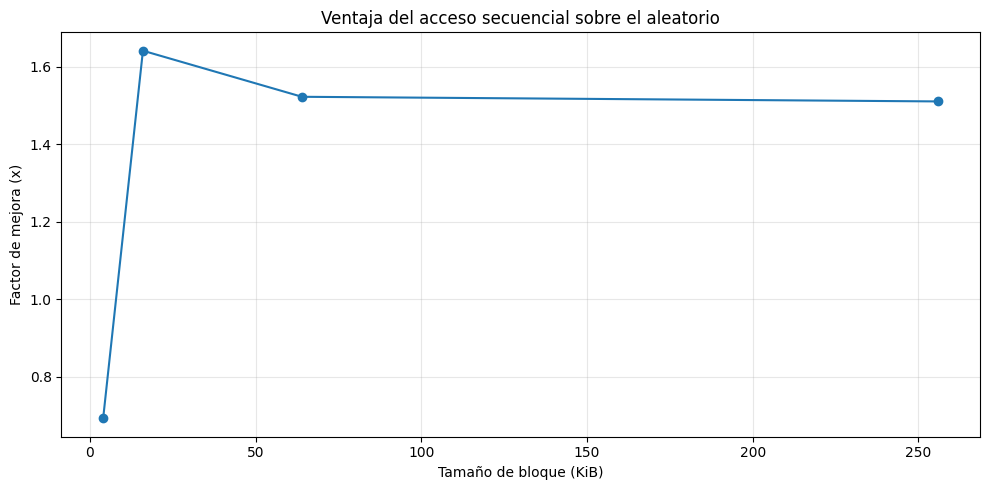

In [18]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- ¿Cuál fue el mayor factor de mejora observado?
- ¿Cómo cambia esa ventaja con el tamaño de bloque?
- ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta
La mayor ventaja del acceso secuencial se observó en bloques de 16 KB, donde alcanzó un factor de mejora de aproximadamente 1.64x, lo que significa que el acceso secuencial fue 1.64 veces más rápido que el acceso aleatorio en ese caso.
A medida que aumenta el tamaño del bloque, la ventaja del acceso secuencial se mantiene relativamente alta, con valores cercanos a 1.5x en bloques de 64 KB y 256 KB. Esto indica que el acceso secuencial sigue siendo más eficiente, aunque la diferencia se estabiliza para bloques grandes.
En bloques pequeños como 4 KB, la ventaja del acceso secuencial es menor (incluso inferior a 1), lo que indica que en ese caso el acceso aleatorio puede ser más rápido.
En términos de diseño de software, esto implica que es recomendable organizar los datos de forma contigua y favorecer patrones de acceso secuencial, ya que esto permite mejorar el rendimiento del sistema, especialmente cuando se manejan grandes volúmenes de información.

## 10. Resumen automático de resultados

In [19]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,2.057240,0.087047,124.438586,179.500936,0.693248
1,16.0,0.280887,0.112553,911.398858,555.292964,1.641294
2,64.0,0.145522,0.216361,1759.189014,1155.473594,1.522483
3,256.0,0.113884,0.671968,2247.897426,1488.166768,1.510514


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información en disco se almacena en bloques, y esto es importante porque el rendimiento no depende solo de cuántos datos se leen, sino también de cómo están organizados y del patrón de acceso utilizado. En este laboratorio se comprobó que el acceso secuencial suele ser más eficiente que el acceso aleatorio, ya que permite leer datos contiguos y reducir la cantidad de accesos costosos al almacenamiento. En mis resultados, por ejemplo, el mayor factor de mejora del acceso secuencial fue de 1.64x con bloques de 16 KB, y además se alcanzó un throughput secuencial de 2247.90 MiB/s con bloques de 256 KB. Aunque el equipo usado tiene un SSD SATA, el acceso aleatorio siguió siendo más costoso debido a la latencia del controlador, la dispersión de los datos y la menor eficiencia al manejar múltiples lecturas independientes. El modelo teórico fue útil como referencia general para entender la tendencia esperada, pero no representó exactamente el comportamiento real, ya que en varios casos sobreestimó el tiempo medido. Esto puede explicarse por factores como la caché del sistema operativo y optimizaciones internas del SSD. Con base en estos resultados, en un sistema real tomaría la decisión de organizar los datos de forma contigua y favorecer lecturas secuenciales, especialmente en aplicaciones como motores de bases de datos, donde minimizar el costo de I/O mejora notablemente el desempeño.

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

- Respuesta: En mis mediciones, el acceso secuencial fue aproximadamente hasta 1.64 veces más rápido que el acceso aleatorio, especialmente en bloques de 16 KB. Este resultado sí era esperado según la teoría, ya que el acceso secuencial reduce la cantidad de accesos al disco y aprovecha mejor la lectura continua de datos.

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

- Respuesta: El throughput del acceso aleatorio aumentó a medida que creció el tamaño de bloque. Por ejemplo, pasó de aproximadamente 179.50 MiB/s en 4 KB a cerca de 1488.17 MiB/s en 256 KB. Esto sucede porque al leer bloques más grandes se reduce la cantidad de accesos independientes al disco, disminuyendo el impacto de la latencia.

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

- Respuesta: Un caso donde la medición empírica se alejó del modelo teórico fue en el acceso secuencial con bloques de 256 KB, donde el tiempo empírico fue de aproximadamente 0.11 s, mientras que el modelo teórico estimaba alrededor de 0.51 s. Esta diferencia puede atribuirse a factores como la caché del sistema operativo y las optimizaciones internas del SSD, que no están contempladas en el modelo teórico simplificado.

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

- Respuesta: Mis resultados se asemejan más al comportamiento de un SSD SATA, ya que el throughput obtenido (hasta aproximadamente 2247.90 MiB/s en secuencial) y los tiempos medidos son mucho mejores que los de un HDD, pero no alcanzan completamente el rendimiento ideal de un SSD NVMe. Además, el comportamiento del acceso aleatorio confirma la presencia de latencias típicas de un SSD.

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

- Resouesta: Preferiría leer la tabla de forma secuencial, ya que este patrón demostró ser más eficiente en términos de tiempo y throughput. Como se observó en los resultados, el acceso secuencial puede ser hasta 1.64 veces más rápido, lo que es especialmente importante cuando se manejan grandes volúmenes de datos como un millón de registros. El acceso aleatorio implicaría múltiples accesos dispersos, aumentando la latencia y reduciendo el rendimiento.

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.